In [13]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rfc = RandomForestClassifier()

# Fit the model on the training data
rfc.fit(X_train, y_train)  # Ensure you have defined X_train and y_train

# Now you can call the score method
accuracy = rfc.score(X_test, y_test)

# Set up for visualizations
sns.set(style="whitegrid")

# Optional: Ignore warnings
import warnings
warnings.filterwarnings('ignore')


NameError: name 'X_train' is not defined

In [2]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\USER\Downloads\archive (47)\recruitment_data.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset with bold headers
print("\033[1mDataset Preview:\033[0m")
print(df.head().to_string(index=False, header=[f"\033[1m{col}\033[0m" for col in df.columns]))

# Print the data type
print("\033[1mData Type:\033[0m")
print(df.dtypes)

# Print the number of unique values in each column with bold column names
print("\n\033[1mNumber of unique values in each column:\033[0m")
for col in df.columns:
    print(f"\033[1m{col}\033[0m: {df[col].nunique()}")

Dataset Preview:
Age Gender EducationLevel ExperienceYears PreviousCompanies DistanceFromCompany InterviewScore SkillScore PersonalityScore RecruitmentStrategy HiringDecision
         26              1                      2                       0                         3                   26.783828                     48                 78                       91                           1                      1
         39              1                      4                      12                         3                   25.862694                     35                 68                       80                           2                      1
         48              0                      2                       3                         2                    9.920805                     20                 67                       13                           2                      0
         34              1                      2                       5              

In this step, we can analyse that Gender, Education Level, RecruitmentStrategy and 
HiringDecisin have 4 or less unique values in each of their respective column. As per the dataset, it is a numerical feature. It would be more insightful for us to convert these numerical values into categorical values. 2

In [3]:
# Convert Gender, RecruitmentStrategy, and EducationLevel to categorical data types
df['Gender'] = df['Gender'].astype('category')
df['RecruitmentStrategy'] = df['RecruitmentStrategy'].astype('category')
df['EducationLevel'] = df['EducationLevel'].astype('category')
df['HiringDecision'] = df['HiringDecision'].astype('category')

# Verify the changes
print("\nUpdated data types:")
print(df.dtypes)

# Confirmation message
print("\nConfirmation: 'Gender', 'RecruitmentStrategy', and 'EducationLevel' have been successfully converted to categorical data types.")


Updated data types:
Age                       int64
Gender                 category
EducationLevel         category
ExperienceYears           int64
PreviousCompanies         int64
DistanceFromCompany     float64
InterviewScore            int64
SkillScore                int64
PersonalityScore          int64
RecruitmentStrategy    category
HiringDecision         category
dtype: object

Confirmation: 'Gender', 'RecruitmentStrategy', and 'EducationLevel' have been successfully converted to categorical data types.


In [4]:
# Display data shape
print("\033[1mData Shape:\033[0m")
print(df.shape)

# Display data frame
print("\n\033[1mData Frame:\033[0m")
print(df.info())

# List categorical and numerical features
categorical_features = df.select_dtypes(include=['category']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n\033[1mCategorical Features:\033[0m")
print(categorical_features)
print(f"\033[1mNumber of Categorical Features:\033[0m {len(categorical_features)}")

print("\n\033[1mNumerical Features:\033[0m")
print(numerical_features)
print(f"\033[1mNumber of Numerical Features:\033[0m {len(numerical_features)}")

# Number of missing values
print("\n\033[1mNumber of Missing Values:\033[0m")
print(df.isnull().sum().sum())

# Number of duplicate rows
print("\n\033[1mNumber of Duplicate Rows:\033[0m")
print(df.duplicated().sum())

Data Shape:
(1500, 11)

Data Frame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  1500 non-null   int64   
 1   Gender               1500 non-null   category
 2   EducationLevel       1500 non-null   category
 3   ExperienceYears      1500 non-null   int64   
 4   PreviousCompanies    1500 non-null   int64   
 5   DistanceFromCompany  1500 non-null   float64 
 6   InterviewScore       1500 non-null   int64   
 7   SkillScore           1500 non-null   int64   
 8   PersonalityScore     1500 non-null   int64   
 9   RecruitmentStrategy  1500 non-null   category
 10  HiringDecision       1500 non-null   category
dtypes: category(4), float64(1), int64(6)
memory usage: 88.6 KB
None

Categorical Features:
['Gender', 'EducationLevel', 'RecruitmentStrategy', 'HiringDecision']
Number of Categorical Features: 

In [5]:
# Function to identify outliers using the IQR method
def identify_outliers(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[column] = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers

# Identify outliers in the dataset
outliers = identify_outliers(df)

# Print the outliers for each column in a statement
for column, outlier_values in outliers.items():
    if not outlier_values.empty:
        print(f"The following outliers were identified in the '{column}' column:")
        print(outlier_values.tolist())
    else:
        print(f"No outliers were identified in the '{column}' column.")
    print("\n" + "="*60 + "\n")



No outliers were identified in the 'Age' column.


No outliers were identified in the 'ExperienceYears' column.


No outliers were identified in the 'PreviousCompanies' column.


No outliers were identified in the 'DistanceFromCompany' column.


No outliers were identified in the 'InterviewScore' column.


No outliers were identified in the 'SkillScore' column.


No outliers were identified in the 'PersonalityScore' column.




In [6]:
# Summary statistics for numerical features (only mean and std)
numerical_summary = df.describe().loc[['mean', 'std']]

print("\033[1mSummary Statistics for Numerical Features (Mean and Std Deviation):\033[0m")
print(numerical_summary)

Summary Statistics for Numerical Features (Mean and Std Deviation):
            Age  ExperienceYears  PreviousCompanies  DistanceFromCompany  \
mean  35.148667         7.694000            3.00200            25.505379   
std    9.252728         4.641414            1.41067            14.567151   

      InterviewScore  SkillScore  PersonalityScore  
mean       50.564000   51.116000         49.387333  
std        28.626215   29.353563         29.353201  


Features sorted by correlation with HiringDecision:
HiringDecision         1.000000
SkillScore             0.203668
PersonalityScore       0.169177
InterviewScore         0.146064
ExperienceYears        0.122494
PreviousCompanies      0.044025
Age                    0.001850
DistanceFromCompany   -0.016791
Name: HiringDecision, dtype: float64


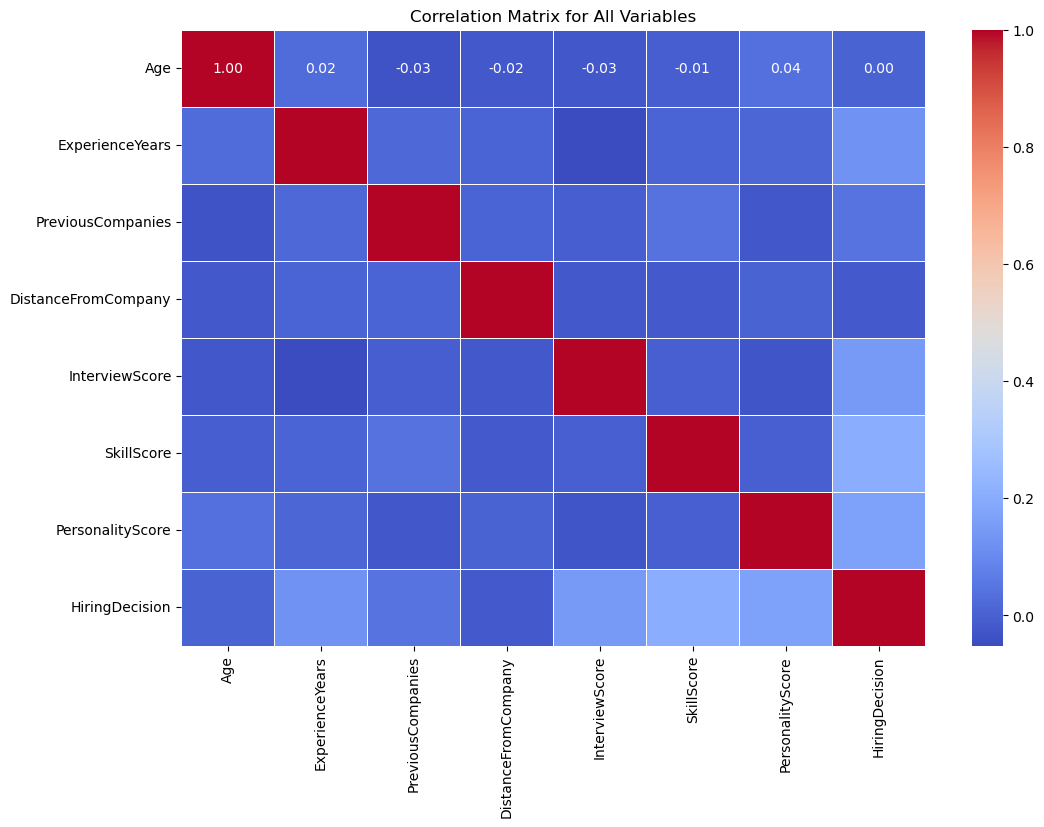

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the target variable 'HiringDecision' to numerical if it's categorical
df['HiringDecision'] = pd.to_numeric(df['HiringDecision'], errors='coerce')

# Select numerical features from the dataset
numerical_features = df[['Age', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'HiringDecision']]

# Compute the correlation matrix for numerical features
numerical_corr_matrix = numerical_features.corr()

# Sort the correlations of features with the target variable 'HiringDecision' from highest to lowest
correlation_with_target = numerical_corr_matrix['HiringDecision'].sort_values(ascending=False)

# Display the sorted correlations
print("Features sorted by correlation with HiringDecision:")
print(correlation_with_target)

# Plot the correlation matrix for numerical variables
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix for All Variables')
plt.show()

Features sorted by correlation with HiringDecision:
HiringDecision         1.000000
SkillScore             0.203668
PersonalityScore       0.169177
InterviewScore         0.146064
ExperienceYears        0.122494
PreviousCompanies      0.044025
Age                    0.001850
DistanceFromCompany   -0.016791
Name: HiringDecision, dtype: float64


C:\Users\USER\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


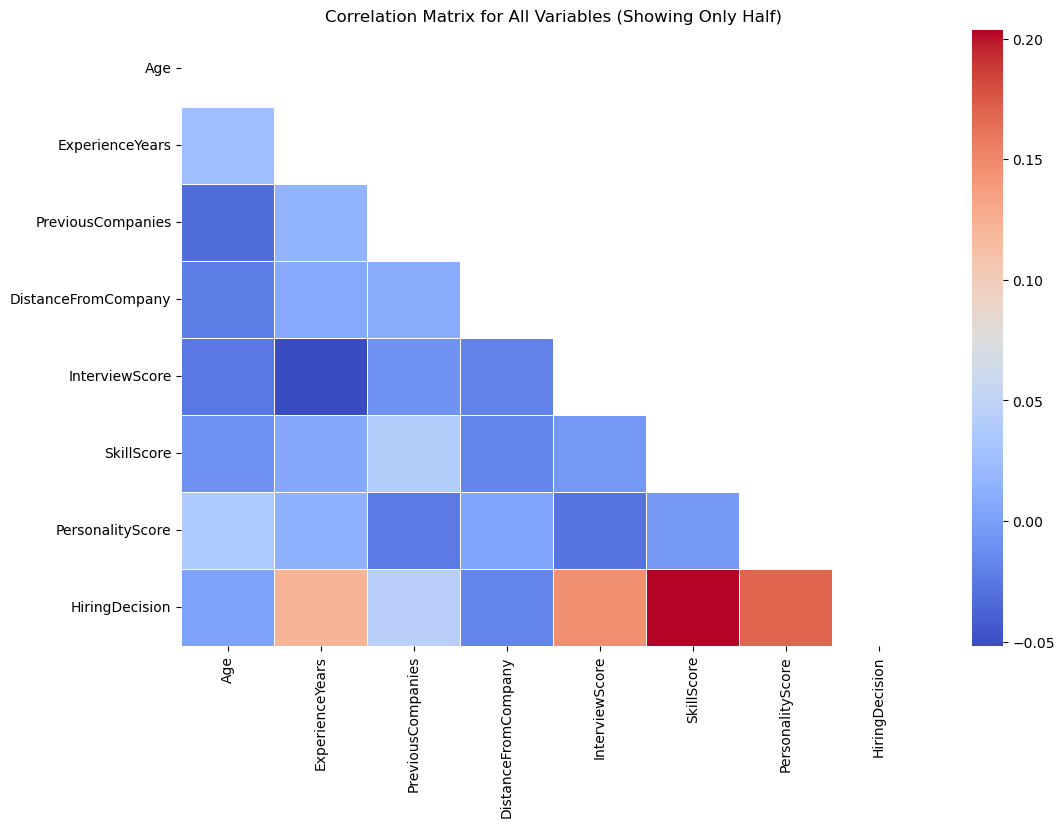

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert the target variable 'HiringDecision' to numerical if it's categorical
df['HiringDecision'] = pd.to_numeric(df['HiringDecision'], errors='coerce')

# Select numerical features from the dataset
numerical_features = df[['Age', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'HiringDecision']]

# Compute the correlation matrix for numerical features
numerical_corr_matrix = numerical_features.corr()

# Sort the correlations of features with the target variable 'HiringDecision' from highest to lowest
correlation_with_target = numerical_corr_matrix['HiringDecision'].sort_values(ascending=False)

# Display the sorted correlations
print("Features sorted by correlation with HiringDecision:")
print(correlation_with_target)

# Plot the correlation matrix for numerical variables (showing only half)
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(numerical_corr_matrix, dtype=bool))
sns.heatmap(numerical_corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask)
plt.title('Correlation Matrix for All Variables (Showing Only Half)')
plt.show()

It is necessary for us to do a correlation amtrix/heatmap to understand which numerical features are highly correlated to the target variable, HiringDecision. From this correlation heatmap, we can now do Explotorary Data Analysis for the top 3 features, EducationLevel, 
SkillScor & P
PersonalitySco.77

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


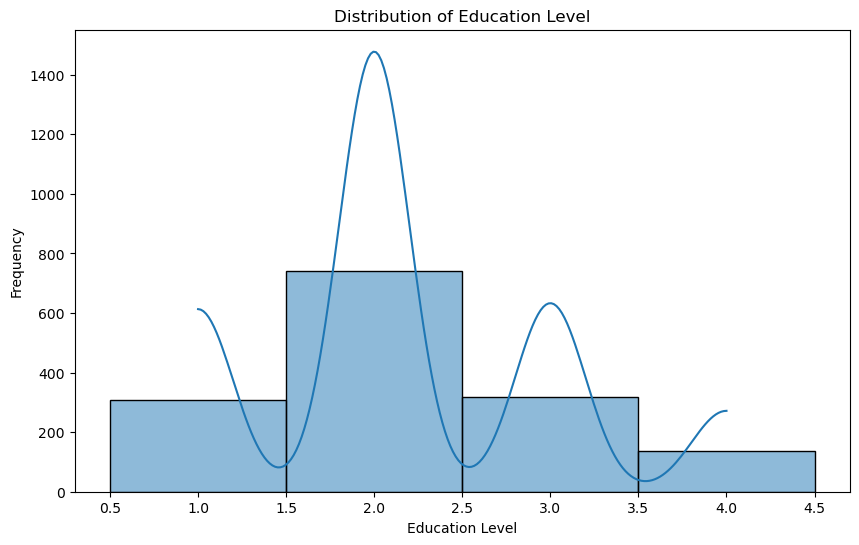

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


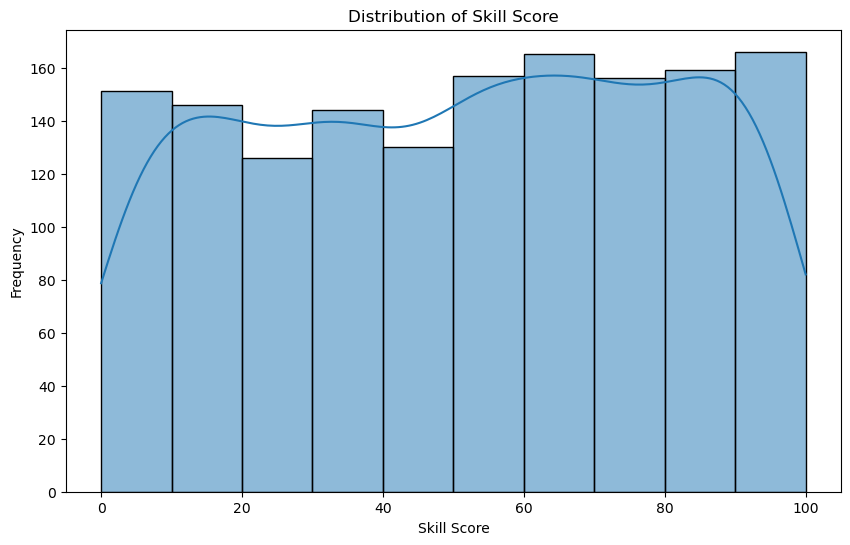

C:\Users\USER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


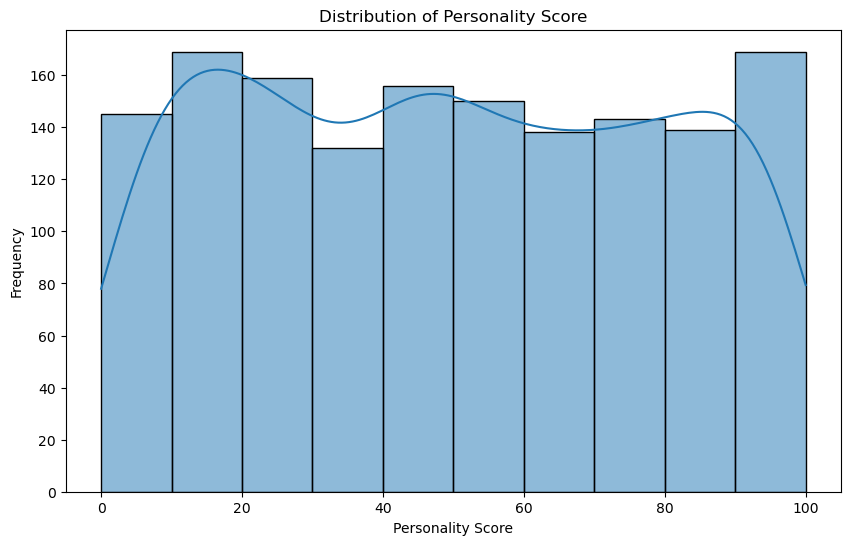

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram with KDE for EducationLevel
plt.figure(figsize=(10, 6))
sns.histplot(df['EducationLevel'], bins=10, kde=True)
plt.title('Distribution of Education Level')
plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.show()

# Histogram with KDE for SkillScore
plt.figure(figsize=(10, 6))
sns.histplot(df['SkillScore'], bins=10, kde=True)
plt.title('Distribution of Skill Score')
plt.xlabel('Skill Score')
plt.ylabel('Frequency')
plt.show()

# Histogram with KDE for PersonalityScore
plt.figure(figsize=(10, 6))
sns.histplot(df['PersonalityScore'], bins=10, kde=True)
plt.title('Distribution of Personality Score')
plt.xlabel('Personality Score')
plt.ylabel('Frequency')
plt.show()


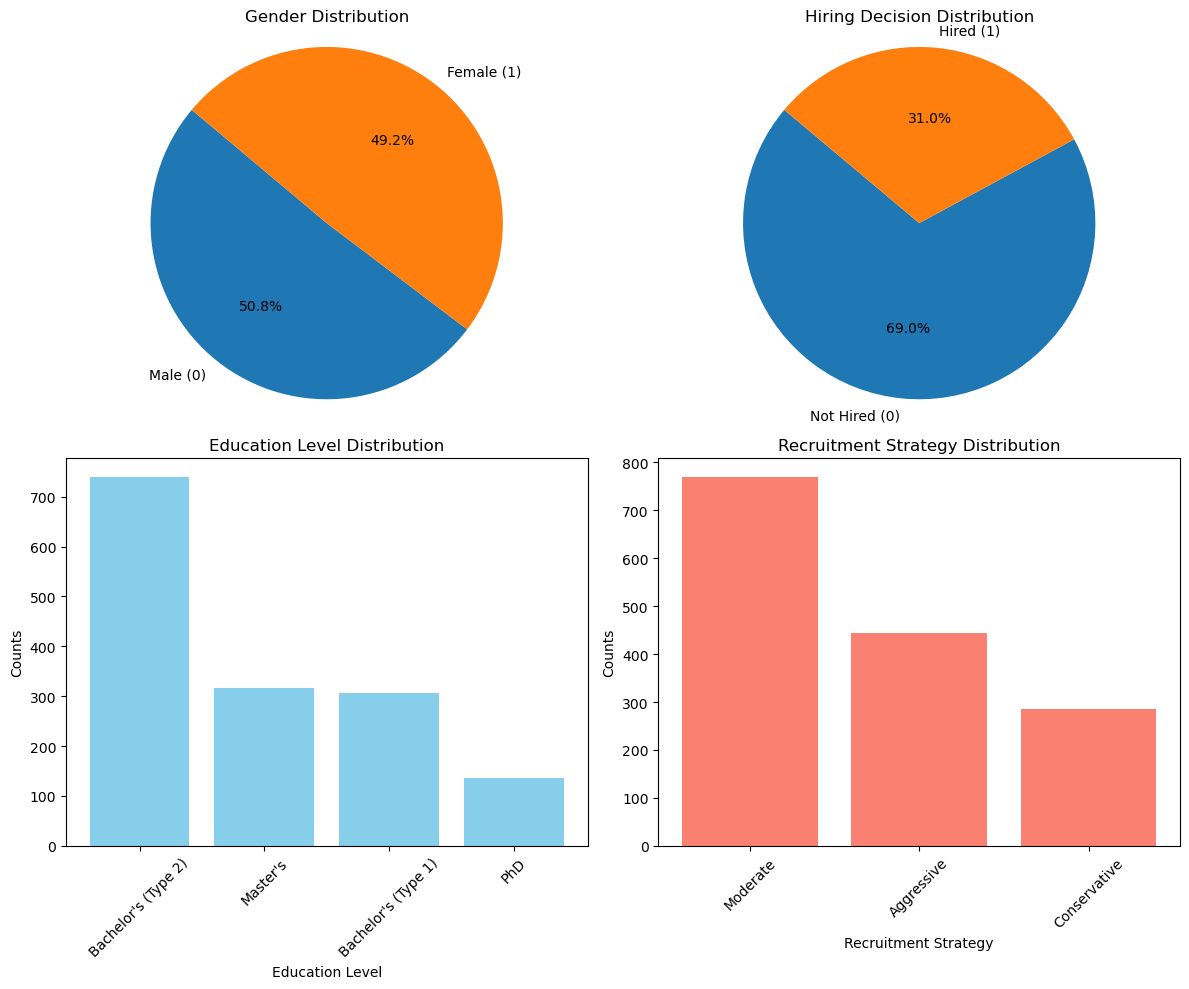

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


# Pie chart for Gender distribution
gender_counts = df['Gender'].value_counts()

# Mapping for Gender
gender_labels = {0: 'Male (0)', 1: 'Female (1)'}
gender_counts.index = gender_counts.index.map(gender_labels)

plt.figure(figsize=(12, 10))

# Pie Chart for Gender
plt.subplot(2, 2, 1)  # 2 rows, 2 columns, 1st subplot
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Pie chart for Hiring Decision distribution
hiring_decision_counts = df['HiringDecision'].value_counts()

# Mapping for Hiring Decision
hiring_labels = {0: 'Not Hired (0)', 1: 'Hired (1)'}
hiring_decision_counts.index = hiring_decision_counts.index.map(hiring_labels)

# Pie Chart for Hiring Decision
plt.subplot(2, 2, 2)  # 2 rows, 2 columns, 2nd subplot
plt.pie(hiring_decision_counts, labels=hiring_decision_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Hiring Decision Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Bar chart for Education Level distribution
plt.subplot(2, 2, 3)  # 2 rows, 2 columns, 3rd subplot
education_counts = df['EducationLevel'].value_counts()

# Mapping for Education Level
education_labels = {
    1: "Bachelor's (Type 1)",
    2: "Bachelor's (Type 2)",
    3: "Master's",
    4: "PhD"
}
education_counts.index = education_counts.index.map(education_labels)

plt.bar(education_counts.index, education_counts.values, color='skyblue')
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Counts')
plt.xticks(rotation=45)

# Bar chart for Recruitment Strategy distribution
plt.subplot(2, 2, 4)  # 2 rows, 2 columns, 4th subplot
recruitment_counts = df['RecruitmentStrategy'].value_counts()

# Mapping for Recruitment Strategy
recruitment_labels = {
    1: "Aggressive",
    2: "Moderate",
    3: "Conservative"
}
recruitment_counts.index = recruitment_counts.index.map(recruitment_labels)

plt.bar(recruitment_counts.index, recruitment_counts.values, color='salmon')
plt.title('Recruitment Strategy Distribution')
plt.xlabel('Recruitment Strategy')
plt.ylabel('Counts')
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()




In [14]:
# Define the features (X) and the target variable (y)
X = df.drop('HiringDecision', axis=1)  # Drop the target column
y = df['HiringDecision']  # Target column

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Standard Scaler to scale the features
scaler = StandardScaler()

# Fit the scaler only on the training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify the scaled data
print("Scaled Training Data (First 5 Rows):")
print(X_train_scaled[:5])

Scaled Training Data (First 5 Rows):
[[ 0.6457784   1.0168079   0.93165673 -0.79528254 -1.40574422  0.07718799
   0.34722025  0.99391022  0.17475903  0.14298599]
 [ 1.29707473  1.0168079   0.93165673 -1.00954815  0.01121761 -0.2057359
   0.76608358 -0.33002097  0.20881959  0.14298599]
 [ 0.86287717  1.0168079  -0.22448399  1.3473736   0.71969853  0.00299797
  -0.31598002 -0.49975573  0.17475903 -1.29888955]
 [-0.65681425 -0.98346994 -0.22448399  0.06177992  0.01121761  0.09564651
   1.0453258   0.07734248  1.02627293  1.58486153]
 [ 1.40562411  1.0168079  -0.22448399 -0.1524857   0.71969853 -0.79086217
  -0.80465391  0.68838764 -0.3361493   0.14298599]]


In [15]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Assuming your DataFrame and preprocessed data are already defined
# X_train, y_train, X_test, y_test, X_train_scaled, X_test_scaled

# Initialize your models
rfc = RandomForestClassifier()
abc = AdaBoostClassifier()
etc = ExtraTreesClassifier()
gbc = GradientBoostingClassifier()
svc = SVC(probability=True)  # SVC requires probability=True for some methods
lgr = LogisticRegression()
xgb_model = xgb.XGBClassifier()
lgb_model = lgb.LGBMClassifier()
cbc = CatBoostClassifier(silent=True)  # Use silent=True to suppress CatBoost output

# Fit each model to the training data
rfc.fit(X_train, y_train)
abc.fit(X_train_scaled, y_train)
etc.fit(X_train, y_train)
gbc.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)
lgr.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)
cbc.fit(X_train, y_train)

# Define your model names and corresponding scores
names = ['RandomForest', 'AdaBoost', 'ExtraTrees', 'GradientBoosting', 'SVM', 'LogisticRegression', 'XGBoost', 'LightGBM', 'CatBoost']
scores = [rfc.score(X_test, y_test), 
          abc.score(X_test_scaled, y_test), 
          etc.score(X_test, y_test), 
          gbc.score(X_test_scaled, y_test), 
          svc.score(X_test_scaled, y_test), 
          lgr.score(X_test_scaled, y_test), 
          xgb_model.score(X_test_scaled, y_test), 
          lgb_model.score(X_test_scaled, y_test), 
          cbc.score(X_test, y_test)]  # Include CatBoost score

# Create DataFrame from the scores and sort them
dd = pd.DataFrame({"scores": scores}, index=names)
dd = dd.sort_values("scores", ascending=False)
dd["scores"] = round(dd["scores"], 2)

# Print confirmation that all models have been trained
print("All models (including boosting models) have been trained successfully.")


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 380, number of negative: 820
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316667 -> initscore=-0.769133
[LightGBM] [Info] Start training from score -0.769133


CatBoostError: features data: pandas.DataFrame column 'Gender' has dtype 'category' but is not in  cat_features list

In [24]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Function to display classification report and ROC-AUC score for each model
def print_classification_report_and_roc_auc(model, model_name, X_test, y_test, scaled=True):
    if scaled:
        predictions = model.predict(X_test_scaled)
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test_scaled)
    else:
        predictions = model.predict(X_test)
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test)
    
    print(f"Classification Report for {model_name}:")
    print(classification_report(y_test, predictions))
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score for {model_name}: {roc_auc:.4f}")
    print("\n" + "="*60 + "\n")

# Ensure all models are correctly instantiated and fitted
cbc.fit(X_train_scaled, y_train)
rfc.fit(X_train, y_train)
abc.fit(X_train_scaled, y_train)
etc.fit(X_train, y_train)
gbc.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)
lgr.fit(X_train_scaled, y_train)
xgb_model = XGBClassifier()
xgb_model.fit(X_train_scaled, y_train)
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_scaled, y_train)

# Generate classification reports and ROC-AUC scores for all models
print_classification_report_and_roc_auc(cbc, "CatBoost", X_test_scaled, y_test)  # Added CatBoost
print_classification_report_and_roc_auc(rfc, "Random Forest", X_test, y_test, scaled=False)
print_classification_report_and_roc_auc(abc, "AdaBoost", X_test_scaled, y_test)
print_classification_report_and_roc_auc(etc, "Extra Trees", X_test, y_test, scaled=False)
print_classification_report_and_roc_auc(gbc, "Gradient Boosting", X_test_scaled, y_test)
print_classification_report_and_roc_auc(svc, "Support Vector Machine", X_test_scaled, y_test)
print_classification_report_and_roc_auc(lgb_model, "LightGBM", X_test_scaled, y_test)

[LightGBM] [Info] Number of positive: 380, number of negative: 820
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316667 -> initscore=-0.769133
[LightGBM] [Info] Start training from score -0.769133
Classification Report for CatBoost:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       215
           1       0.93      0.91      0.92        85

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.95      0.95       300

ROC-AUC Score for CatBoost: 0.9292


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0    

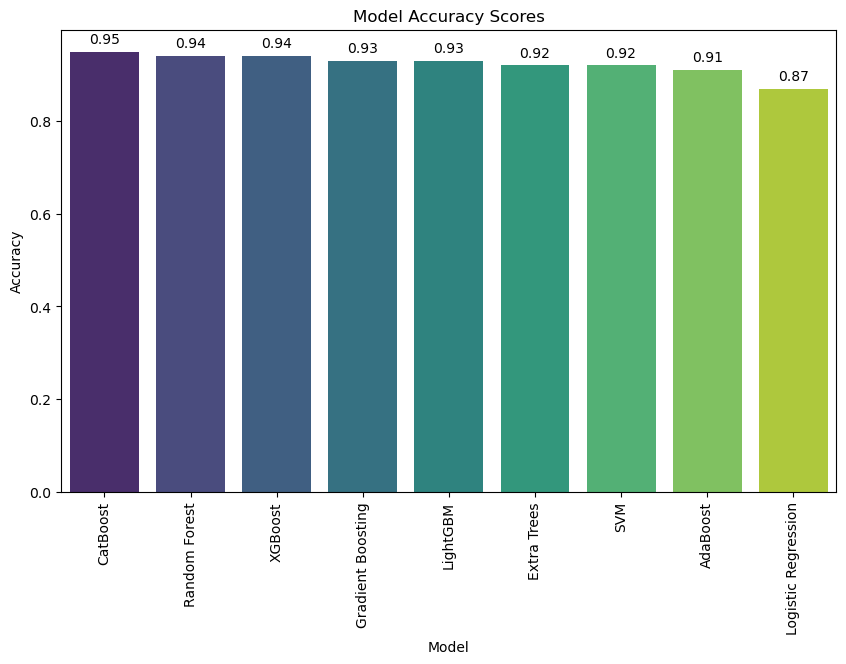

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores from the classification reports
accuracy_scores = {
    'CatBoost': 0.95,
    'Random Forest': 0.94,
    'XGBoost': 0.94,
    'Gradient Boosting': 0.93,
    'LightGBM': 0.93,
    'Extra Trees': 0.92,
    'SVM': 0.92,
    'AdaBoost': 0.91,
    'Logistic Regression': 0.87
}

# Create a DataFrame from the accuracy scores
df_accuracy = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])

# Sort the DataFrame by accuracy in descending order
df_accuracy = df_accuracy.sort_values(by='Accuracy', ascending=False)

# Plot the accuracy scores in a vertical bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Model', y='Accuracy', data=df_accuracy, palette='viridis')

# Add the accuracy scores on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Model Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores from the classification reports
accuracy_scores = {
    'CatBoost': 0.95,
    'Random Forest': 0.94,
    'XGBoost': 0.94,
    'Gradient Boosting': 0.93,
    'LightGBM': 0.93,
    'Extra Trees': 0.92,
    'SVM': 0.92,
    'AdaBoost': 0.91,
    'Logistic Regression': 0.87,
    'DNN': 0.92  # Add DNN accuracy
}

# Create a DataFrame from the accuracy scores
df_accuracy = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])

# Sort the DataFrame by accuracy in descending order
df_accuracy = df_accuracy.sort_values(by='Accuracy', ascending=False)

# Plot the accuracy scores in a vertical bar chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x='Model', y='Accuracy', data=df_accuracy, palette='viridis')

# Add the accuracy scores on top of each bar
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.title('Model Accuracy Scores')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.show()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 380, number of negative: 820
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 628
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316667 -> initscore=-0.769133
[LightGBM] [Info] Start training from score -0.769133


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


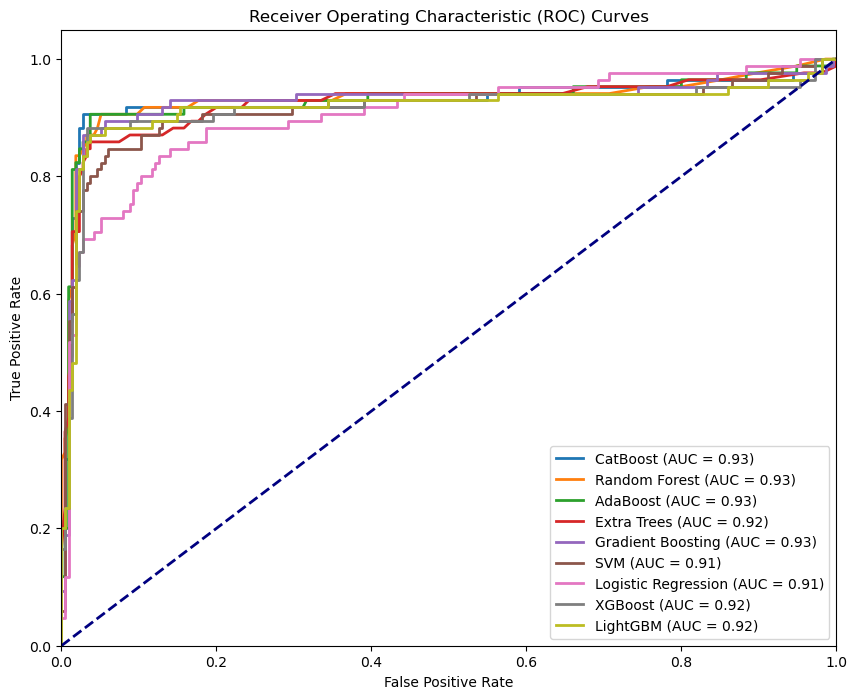

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Function to plot ROC curve for each model
def plot_roc_curve(model, X_test, y_test, model_name, scaled=True):
    if scaled:
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Ensure all models are correctly instantiated and fitted
cbc.fit(X_train_scaled, y_train)
rfc.fit(X_train, y_train)
abc.fit(X_train_scaled, y_train)
etc.fit(X_train, y_train)
gbc.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)
lgr.fit(X_train_scaled, y_train)
xgb_model = XGBClassifier()
xgb_model.fit(X_train_scaled, y_train)
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_scaled, y_train)

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

plot_roc_curve(cbc, X_test_scaled, y_test, 'CatBoost')
plot_roc_curve(rfc, X_test, y_test, 'Random Forest', scaled=False)
plot_roc_curve(abc, X_test_scaled, y_test, 'AdaBoost')
plot_roc_curve(etc, X_test, y_test, 'Extra Trees', scaled=False)
plot_roc_curve(gbc, X_test_scaled, y_test, 'Gradient Boosting')
plot_roc_curve(svc, X_test_scaled, y_test, 'SVM')
plot_roc_curve(lgr, X_test_scaled, y_test, 'Logistic Regression')
plot_roc_curve(xgb_model, X_test_scaled, y_test, 'XGBoost')
plot_roc_curve(lgb_model, X_test_scaled, y_test, 'LightGBM')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6347 - loss: 0.6145 - val_accuracy: 0.8000 - val_loss: 0.4882
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8392 - loss: 0.4123 - val_accuracy: 0.8042 - val_loss: 0.4566
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8766 - loss: 0.3168 - val_accuracy: 0.8000 - val_loss: 0.4478
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8897 - loss: 0.3360 - val_accuracy: 0.8250 - val_loss: 0.4164
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8875 - loss: 0.2884 - val_accuracy: 0.8208 - val_loss: 0.4185
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9068 - loss: 0.2676 - val_accuracy: 0.8167 - val_loss: 0.4163
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9055 - loss: 0.2476 - val_accuracy: 0.8083 - val_loss: 0.4192
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8963 - loss: 0.2765 - val_accuracy: 0.8208 - val_loss

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 380, number of negative: 820
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316667 -> initscore=-0.769133
[LightGBM] [Info] Start training from score -0.769133
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


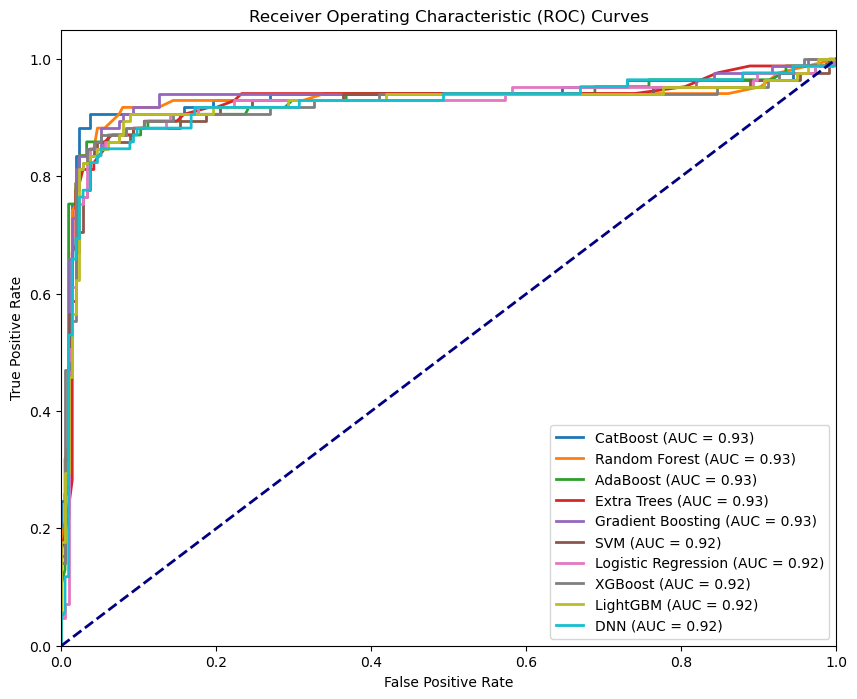

In [94]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Build the DNN model
model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Predict and evaluate
y_pred_dnn = (model.predict(X_test_scaled) > 0.5).astype(int)
print("DNN Classification Report:")
print(classification_report(y_test, y_pred_dnn, target_names=["Not Hired", "Hired"]))

# Function to plot ROC curve for each model
def plot_roc_curve(model, X_test, y_test, model_name, scaled=True):
    if hasattr(model, 'predict_proba'):
        if scaled:
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.predict(X_test_scaled).ravel()
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Ensure all models are correctly instantiated and fitted
cbc.fit(X_train_scaled, y_train)
rfc.fit(X_train, y_train)
abc.fit(X_train_scaled, y_train)
etc.fit(X_train, y_train)
gbc.fit(X_train_scaled, y_train)
svc.fit(X_train_scaled, y_train)
lgr.fit(X_train_scaled, y_train)
xgb_model = XGBClassifier()
xgb_model.fit(X_train_scaled, y_train)
lgb_model = LGBMClassifier()
lgb_model.fit(X_train_scaled, y_train)

# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

plot_roc_curve(cbc, X_test_scaled, y_test, 'CatBoost')
plot_roc_curve(rfc, X_test, y_test, 'Random Forest', scaled=False)
plot_roc_curve(abc, X_test_scaled, y_test, 'AdaBoost')
plot_roc_curve(etc, X_test, y_test, 'Extra Trees', scaled=False)
plot_roc_curve(gbc, X_test_scaled, y_test, 'Gradient Boosting')
plot_roc_curve(svc, X_test_scaled, y_test, 'SVM')
plot_roc_curve(lgr, X_test_scaled, y_test, 'Logistic Regression')
plot_roc_curve(xgb_model, X_test_scaled, y_test, 'XGBoost')
plot_roc_curve(lgb_model, X_test_scaled, y_test, 'LightGBM')
plot_roc_curve(model, X_test_scaled, y_test, 'DNN')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


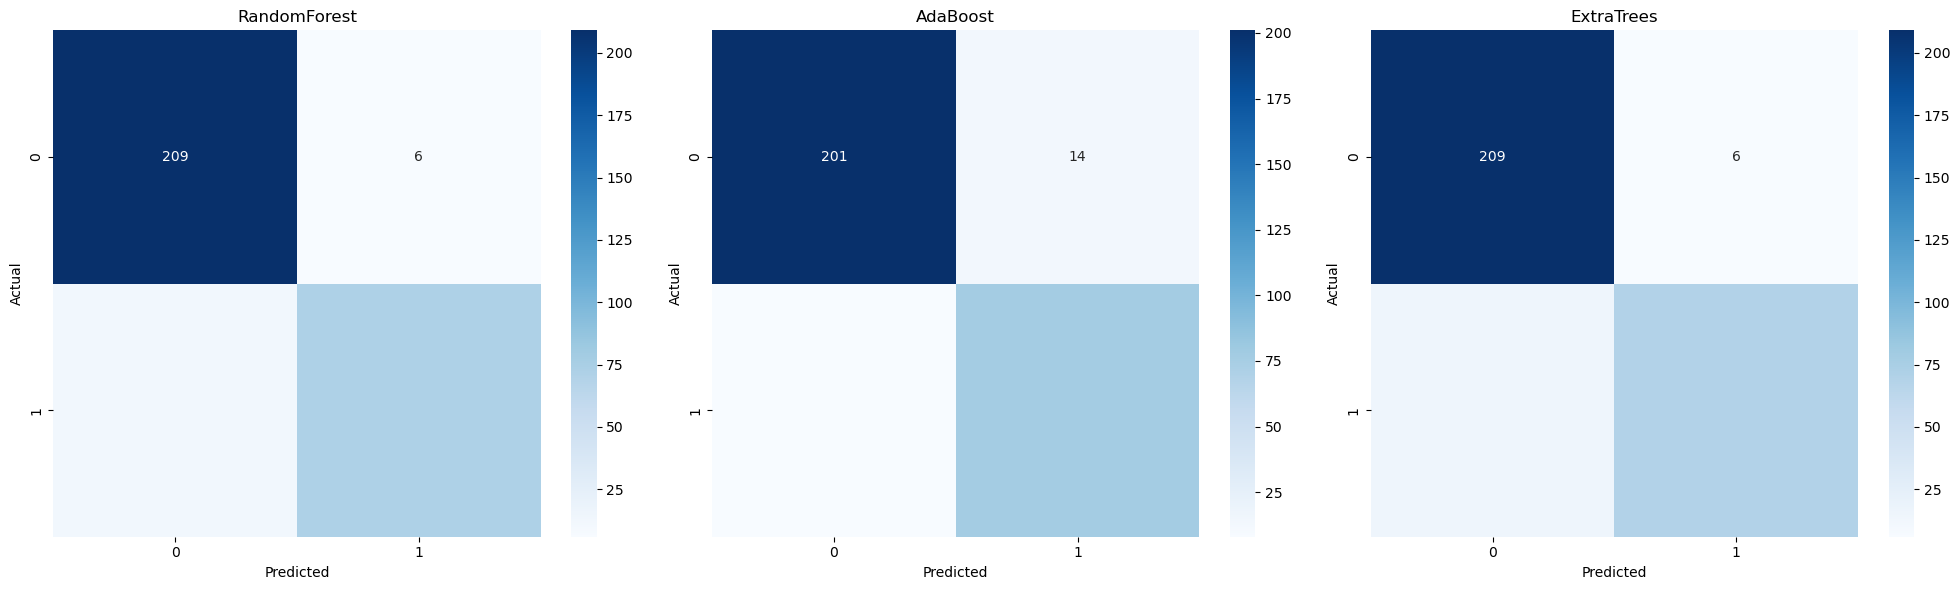

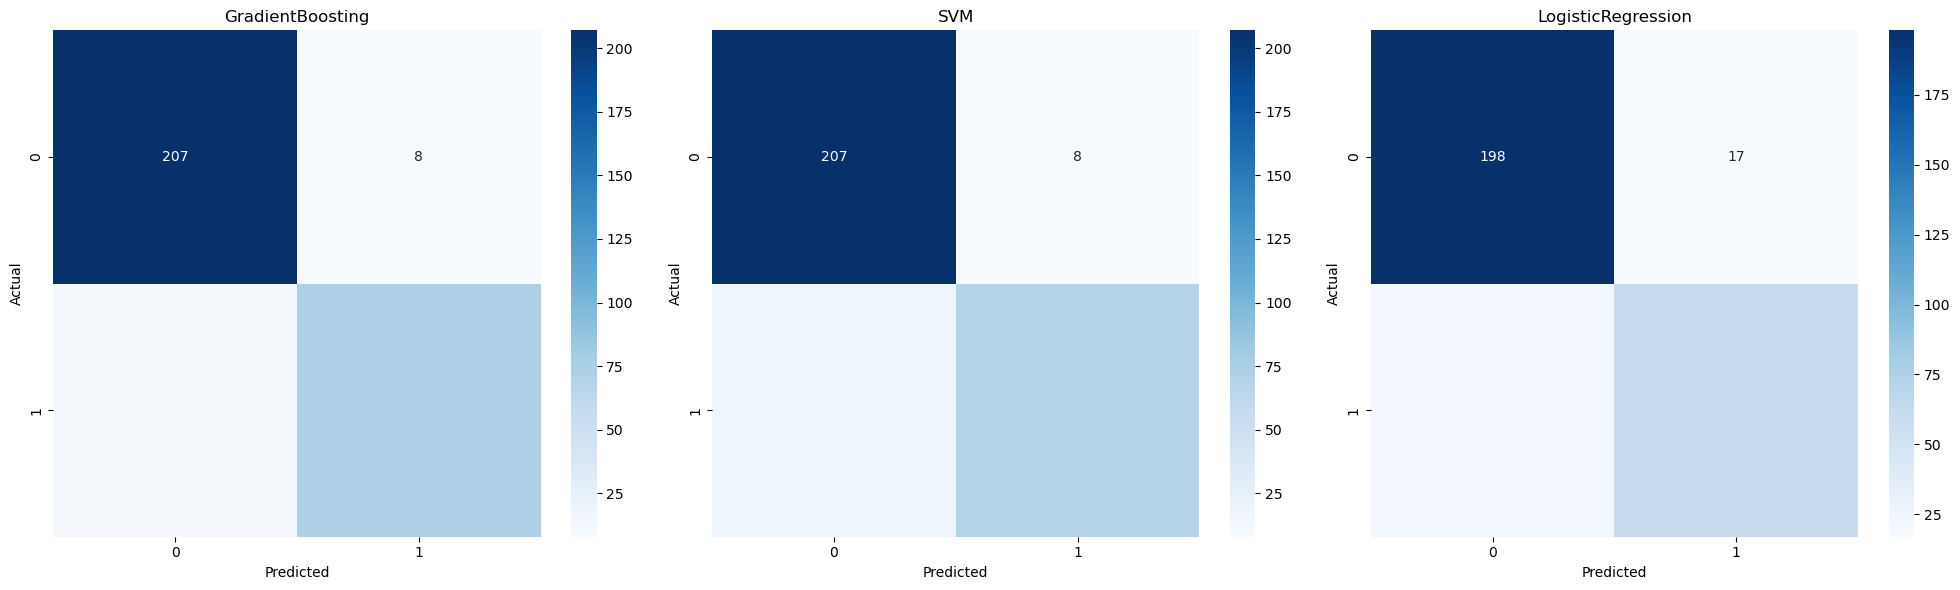

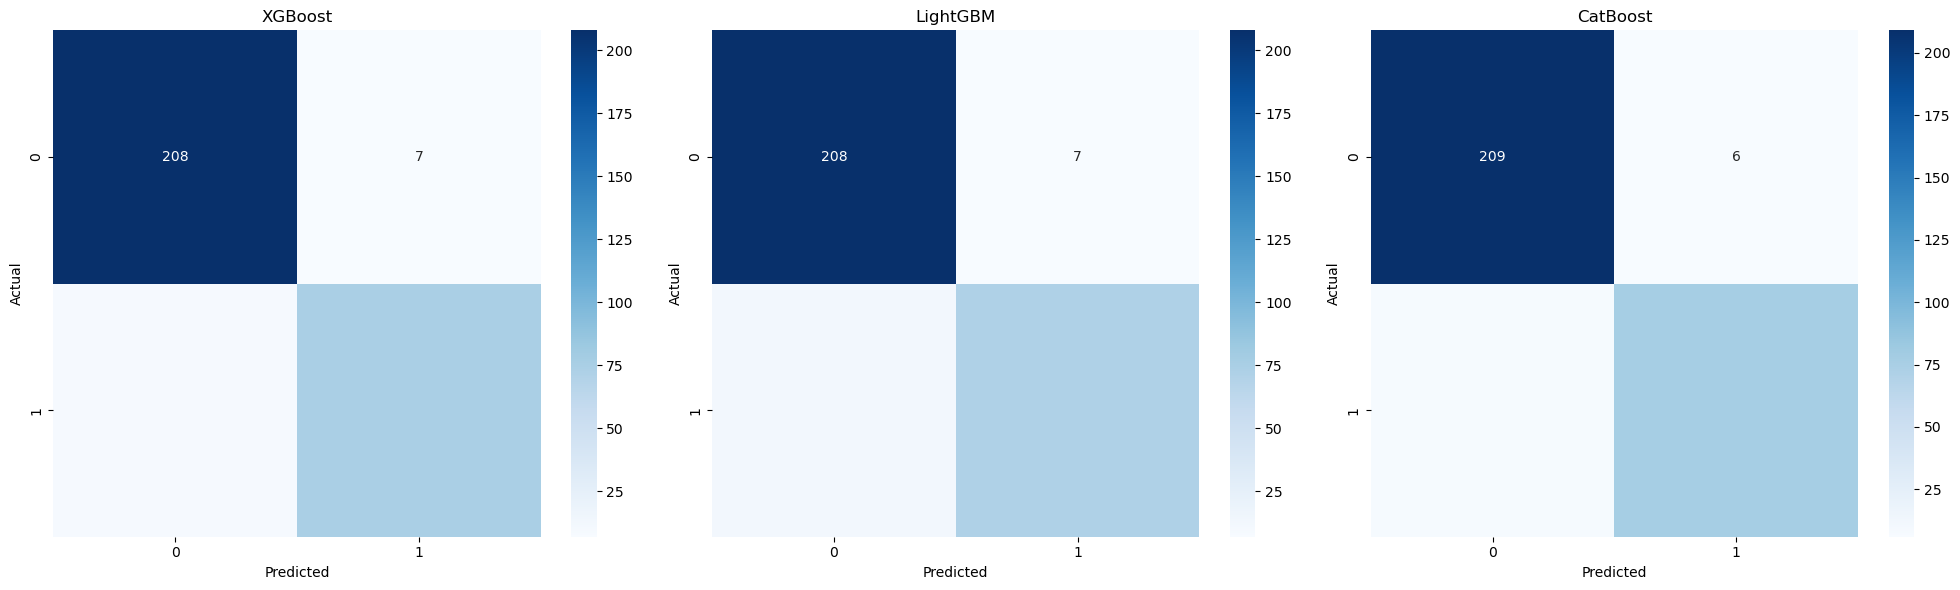

In [18]:
from sklearn.metrics import confusion_matrix

# Assuming `X_test` and `y_test` are already defined and models are trained
cms = {
    'RandomForest': confusion_matrix(y_test, rfc.predict(X_test)),
    'AdaBoost': confusion_matrix(y_test, abc.predict(X_test_scaled)),
    'ExtraTrees': confusion_matrix(y_test, etc.predict(X_test)),
    'GradientBoosting': confusion_matrix(y_test, gbc.predict(X_test_scaled)),
    'SVM': confusion_matrix(y_test, svc.predict(X_test_scaled)),
    'LogisticRegression': confusion_matrix(y_test, lgr.predict(X_test_scaled)),
    'XGBoost': confusion_matrix(y_test, xgb_model.predict(X_test_scaled)),  # Ensure xgb_model is defined
    'LightGBM': confusion_matrix(y_test, lgb_model.predict(X_test_scaled)),  # Ensure lgb_model is defined
    'CatBoost': confusion_matrix(y_test, cbc.predict(X_test_scaled))  # Ensure cbc is defined
}

index = 0
total_models = len(cms)
cols = 3  # Number of columns in the grid

# Calculate the number of rows needed
rows = (total_models + cols - 1) // cols

# Plot in a grid
for i in range(rows):
    fig, axes = plt.subplots(ncols=cols, figsize=(20, 6))  # Adjust the size if needed
    for j in range(cols):
        if index < total_models:
            model_name = list(cms.keys())[index]
            sns.heatmap(cms[model_name], annot=True, fmt='d', ax=axes[j], cmap='Blues')
            axes[j].set_title(model_name)
            axes[j].set_xlabel('Predicted')
            axes[j].set_ylabel('Actual')
            index += 1
        else:
            axes[j].axis('off')  # Turn off the axis if there are no more models to plot
    plt.tight_layout()
    plt.show()



In [19]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

param_grid_rfc = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8]
}

param_grid_cbc = {
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3]
}

# Initialize models
rfc = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
cbc = CatBoostClassifier(random_state=42, verbose=0)

# GridSearchCV for RandomForestClassifier
grid_search_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid_rfc, cv=5, n_jobs=-1, verbose=2)
grid_search_rfc.fit(X_train_scaled, y_train)

# GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv=5, n_jobs=-1, verbose=2)
grid_search_xgb.fit(X_train_scaled, y_train)

# GridSearchCV for CatBoost
grid_search_cbc = GridSearchCV(estimator=cbc, param_grid=param_grid_cbc, cv=5, n_jobs=-1, verbose=2)
grid_search_cbc.fit(X_train_scaled, y_train)

# Print best parameters and scores for GridSearchCV
print("GridSearchCV Best parameters for RandomForest:", grid_search_rfc.best_params_)
print("GridSearchCV Best score for RandomForest:", grid_search_rfc.best_score_)

print("GridSearchCV Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("GridSearchCV Best score for XGBoost:", grid_search_xgb.best_score_)

print("GridSearchCV Best parameters for CatBoost:", grid_search_cbc.best_params_)
print("GridSearchCV Best score for CatBoost:", grid_search_cbc.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Fitting 5 folds for each of 54 candidates, totalling 270 fits
GridSearchCV Best parameters for RandomForest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
GridSearchCV Best score for RandomForest: 0.9241666666666667
GridSearchCV Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
GridSearchCV Best score for XGBoost: 0.9316666666666666
GridSearchCV Best parameters for CatBoost: {'depth': 8, 'iterations': 50, 'l2_leaf_reg': 3, 'learning_rate': 0.2}
GridSearchCV Best score for CatBoost: 0.9541666666666668


In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

param_grid_rfc = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8]
}

param_grid_cbc = {
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'l2_leaf_reg': [1, 3]
}

# Initialize models
rfc = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
cbc = CatBoostClassifier(random_state=42, verbose=0)

# RandomizedSearchCV for RandomForestClassifier
random_search_rfc = RandomizedSearchCV(estimator=rfc, param_distributions=param_grid_rfc, n_iter=20, cv=5, n_jobs=-1, verbose=2, random_state=42)
random_search_rfc.fit(X_train_scaled, y_train)

# RandomizedSearchCV for XGBoost
random_search_xgb = RandomizedSearchCV(estimator=xgb, param_distributions=param_grid_xgb, n_iter=20, cv=5, n_jobs=-1, verbose=2, random_state=42)
random_search_xgb.fit(X_train_scaled, y_train)

# RandomizedSearchCV for CatBoost
random_search_cbc = RandomizedSearchCV(estimator=cbc, param_distributions=param_grid_cbc, n_iter=20, cv=5, n_jobs=-1, verbose=2, random_state=42)
random_search_cbc.fit(X_train_scaled, y_train)

# Print best parameters and scores for RandomizedSearchCV
print("RandomizedSearchCV Best parameters for RandomForest:", random_search_rfc.best_params_)
print("RandomizedSearchCV Best score for RandomForest:", random_search_rfc.best_score_)

print("RandomizedSearchCV Best parameters for XGBoost:", random_search_xgb.best_params_)
print("RandomizedSearchCV Best score for XGBoost:", random_search_xgb.best_score_)

print("RandomizedSearchCV Best parameters for CatBoost:", random_search_cbc.best_params_)
print("RandomizedSearchCV Best score for CatBoost:", random_search_cbc.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV Best parameters for RandomForest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
RandomizedSearchCV Best score for RandomForest: 0.9225
RandomizedSearchCV Best parameters for XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1}
RandomizedSearchCV Best score for XGBoost: 0.9291666666666668
RandomizedSearchCV Best parameters for CatBoost: {'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 8}
RandomizedSearchCV Best score for CatBoost: 0.9541666666666666


Performance Metrics for RandomForest:
Accuracy: 0.94
ROC-AUC: 0.9154582763337893
Confusion Matrix:
 [[209   6]
 [ 12  73]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       215
           1       0.92      0.86      0.89        85

    accuracy                           0.94       300
   macro avg       0.93      0.92      0.92       300
weighted avg       0.94      0.94      0.94       300



Cross-Validation Scores for RandomForest: [0.925      0.925      0.94166667 0.92916667 0.9       ]
Mean CV Score for RandomForest: 0.9241666666666667




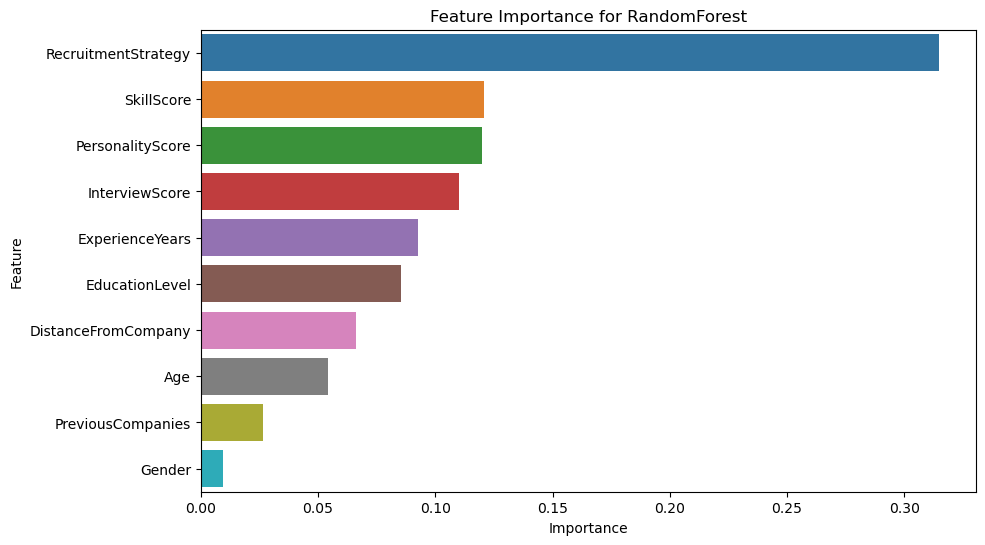

Performance Metrics for XGBoost:
Accuracy: 0.9433333333333334
ROC-AUC: 0.9248974008207934
Confusion Matrix:
 [[208   7]
 [ 10  75]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       215
           1       0.91      0.88      0.90        85

    accuracy                           0.94       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300



Cross-Validation Scores for XGBoost: [0.93333333 0.94166667 0.93333333 0.92916667 0.875     ]
Mean CV Score for XGBoost: 0.9225000000000001




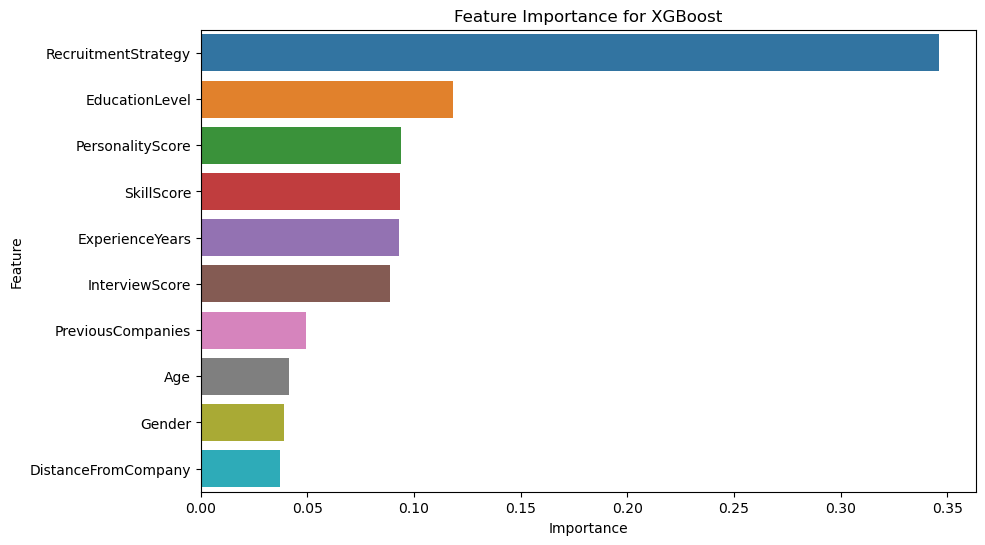

Performance Metrics for CatBoost:
Accuracy: 0.9533333333333334
ROC-AUC: 0.9354309165526675
Confusion Matrix:
 [[210   5]
 [  9  76]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       215
           1       0.94      0.89      0.92        85

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.95      0.95       300



Cross-Validation Scores for CatBoost: [0.95416667 0.95833333 0.9625     0.95       0.94583333]
Mean CV Score for CatBoost: 0.9541666666666668




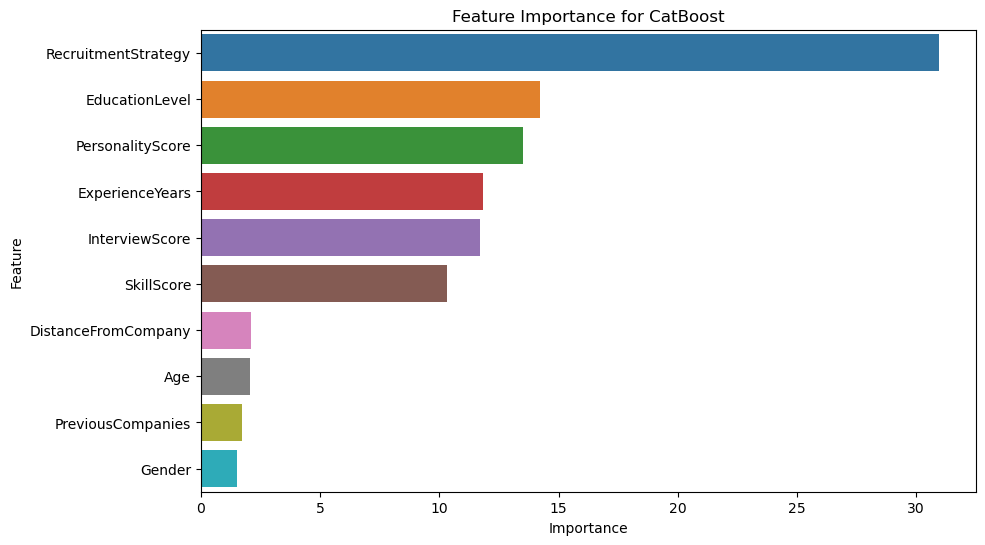

In [22]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_score

# Evaluate the tuned models
best_rfc = grid_search_rfc.best_estimator_
best_xgb = grid_search_xgb.best_estimator_
best_cbc = grid_search_cbc.best_estimator_

models = {
    'RandomForest': best_rfc,
    'XGBoost': best_xgb,
    'CatBoost': best_cbc
}

for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"Performance Metrics for {model_name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n" + "="*60 + "\n")

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    print(f"Cross-Validation Scores for {model_name}:", cv_scores)
    print(f"Mean CV Score for {model_name}:", cv_scores.mean())
    print("\n" + "="*60 + "\n")

    # Feature importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_names = X_train.columns
        feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

        # Plot feature importances
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'Feature Importance for {model_name}')
        plt.show()

    # Save the model
    joblib.dump(model, f'{model_name}_best_model.pkl')


In [23]:
pip install catboost


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: catboost in c:\users\user\anaconda3\lib\site-packages (1.2.7)




[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Required Libraries
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize individual ensemble models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
catboost = CatBoostClassifier(verbose=0, random_state=42)

# Define a stacking classifier
stacked_model = StackingClassifier(
    estimators=[("rf", rf), ("xgb", xgb), ("catboost", catboost)],
    final_estimator=LogisticRegression(),
    cv=5,
)

# Train and evaluate the individual models and the stacked model
models = {"Random Forest": rf, "XGBoost": xgb, "CatBoost": catboost, "Stacked Model": stacked_model}
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["Not Hired", "Hired"])
    results[name] = {"Accuracy": accuracy, "Report": report}

# Print results for each model
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Accuracy: {metrics['Accuracy']:.2f}")
    print(f"Classification Report:\n{metrics['Report']}")
    print("-" * 50)


C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:18:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:18:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:18:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:18:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,

Model: Random Forest
Accuracy: 0.93
Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.94      0.97      0.95       215
       Hired       0.91      0.85      0.88        85

    accuracy                           0.93       300
   macro avg       0.93      0.91      0.92       300
weighted avg       0.93      0.93      0.93       300

--------------------------------------------------
Model: XGBoost
Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.95      0.97      0.96       215
       Hired       0.91      0.88      0.90        85

    accuracy                           0.94       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300

--------------------------------------------------
Model: CatBoost
Accuracy: 0.95
Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.96

In [25]:
# Feature importance for CatBoost
catboost_importances = catboost.feature_importances_
feature_names = X.columns
sorted_importances = sorted(zip(catboost_importances, feature_names), reverse=True)
print("Feature Importance (CatBoost):")
for score, feature in sorted_importances:
    print(f"{feature}: {score:.2f}")

# Feature importance for Random Forest
rf_importances = rf.feature_importances_
sorted_rf_importances = sorted(zip(rf_importances, feature_names), reverse=True)
print("\nFeature Importance (Random Forest):")
for score, feature in sorted_rf_importances:
    print(f"{feature}: {score:.2f}")


Feature Importance (CatBoost):
RecruitmentStrategy: 24.19
PersonalityScore: 14.59
SkillScore: 13.17
InterviewScore: 12.45
EducationLevel: 12.36
ExperienceYears: 12.05
DistanceFromCompany: 3.35
Age: 3.20
PreviousCompanies: 2.71
Gender: 1.94

Feature Importance (Random Forest):
RecruitmentStrategy: 0.31
PersonalityScore: 0.12
SkillScore: 0.12
InterviewScore: 0.11
ExperienceYears: 0.10
EducationLevel: 0.08
DistanceFromCompany: 0.07
Age: 0.06
PreviousCompanies: 0.03
Gender: 0.01


In [26]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
pip install lime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train_scaled, 
    feature_names=X.columns,
    class_names=["Not Hired", "Hired"],
    mode='classification'
)
exp = explainer.explain_instance(
    X_test_scaled[0], 
    stacked_model.predict_proba
)
exp.show_in_notebook()


In [29]:
# Generate predictions
y_pred_probs = model.predict(X_test_scaled)

# Convert probabilities to binary labels
y_pred = (y_pred_probs > 0.5).astype(int)


In [30]:
from sklearn.metrics import classification_report, accuracy_score

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Hired", "Hired"]))


Accuracy: 0.95
Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.96      0.97      0.97       215
       Hired       0.93      0.91      0.92        85

    accuracy                           0.95       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.95      0.95       300



In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate the model
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=["Not Hired", "Hired"]))


KNN Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.88      0.95      0.92       215
       Hired       0.85      0.68      0.76        85

    accuracy                           0.88       300
   macro avg       0.87      0.82      0.84       300
weighted avg       0.87      0.88      0.87       300



In [32]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Initialize the Gaussian Naive Bayes classifier
nb = GaussianNB()

# Train the model
nb.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_nb = nb.predict(X_test_scaled)

# Evaluate the model
print("Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=["Not Hired", "Hired"]))


Naive Bayes Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.91      0.97      0.94       215
       Hired       0.90      0.75      0.82        85

    accuracy                           0.91       300
   macro avg       0.90      0.86      0.88       300
weighted avg       0.91      0.91      0.90       300



In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize the Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_dt = dt.predict(X_test_scaled)

# Evaluate the model
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=["Not Hired", "Hired"]))


Decision Tree Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.94      0.89      0.91       215
       Hired       0.76      0.85      0.80        85

    accuracy                           0.88       300
   macro avg       0.85      0.87      0.86       300
weighted avg       0.89      0.88      0.88       300



In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Initialize the MLP classifier (Simple neural network)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate the model
print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=["Not Hired", "Hired"]))


MLP Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.93      0.96      0.94       215
       Hired       0.88      0.81      0.85        85

    accuracy                           0.92       300
   macro avg       0.91      0.88      0.89       300
weighted avg       0.92      0.92      0.92       300



In [35]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report

# Initialize the QDA classifier
qda = QuadraticDiscriminantAnalysis()

# Train the model
qda.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_qda = qda.predict(X_test_scaled)

# Evaluate the model
print("QDA Classification Report:")
print(classification_report(y_test, y_pred_qda, target_names=["Not Hired", "Hired"]))


QDA Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.93      0.95      0.94       215
       Hired       0.86      0.81      0.84        85

    accuracy                           0.91       300
   macro avg       0.89      0.88      0.89       300
weighted avg       0.91      0.91      0.91       300



In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import classification_report

# Initialize the ElasticNet classifier
elastic_net = ElasticNet(random_state=42)

# Train the model
elastic_net.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_en = elastic_net.predict(X_test_scaled)
y_pred_en = (y_pred_en > 0.5).astype(int)  # Convert continuous output to binary class

# Evaluate the model
print("Elastic Net Classification Report:")
print(classification_report(y_test, y_pred_en, target_names=["Not Hired", "Hired"]))


Elastic Net Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.72      1.00      0.83       215
       Hired       0.00      0.00      0.00        85

    accuracy                           0.72       300
   macro avg       0.36      0.50      0.42       300
weighted avg       0.51      0.72      0.60       300



C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report

# Build the DNN model
model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Predict and evaluate
y_pred_dnn = (model.predict(X_test_scaled) > 0.5).astype(int)
print("DNN Classification Report:")
print(classification_report(y_test, y_pred_dnn, target_names=["Not Hired", "Hired"]))


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6604 - loss: 0.6134 - val_accuracy: 0.7958 - val_loss: 0.4747
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8254 - loss: 0.4102 - val_accuracy: 0.7958 - val_loss: 0.4311
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8645 - loss: 0.3349 - val_accuracy: 0.7917 - val_loss: 0.4261
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8592 - loss: 0.3240 - val_accuracy: 0.8083 - val_loss: 0.4157
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8595 - loss: 0.3475 - val_accuracy: 0.8042 - val_loss: 0.4376
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8675 - loss: 0.3192 - val_accuracy: 0.8125 - val_loss: 0.4586
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8466 - loss: 0.3635 - val_accuracy: 0.8042 - val_loss: 0.4370
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8879 - loss: 0.2809 - val_accuracy: 0.8167 - val_loss

In [38]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize and train the HistGradientBoosting model
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_hgb = hgb.predict(X_test_scaled)
print("HistGradientBoosting Classification Report:")
print(classification_report(y_test, y_pred_hgb, target_names=["Not Hired", "Hired"]))


HistGradientBoosting Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.95      0.96      0.96       215
       Hired       0.90      0.87      0.89        85

    accuracy                           0.94       300
   macro avg       0.93      0.92      0.92       300
weighted avg       0.94      0.94      0.94       300



In [39]:
from sklearn.svm import SVC

# Initialize and train SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)
print("SVM with RBF Kernel Classification Report:")
print(classification_report(y_test, y_pred_svm_rbf, target_names=["Not Hired", "Hired"]))


SVM with RBF Kernel Classification Report:
              precision    recall  f1-score   support

   Not Hired       0.92      0.96      0.94       215
       Hired       0.89      0.80      0.84        85

    accuracy                           0.92       300
   macro avg       0.91      0.88      0.89       300
weighted avg       0.92      0.92      0.92       300



In [40]:
pip install h2o


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the model
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6987 - loss: 0.6215 - val_accuracy: 0.6708 - val_loss: 0.5689
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7028 - loss: 0.5604 - val_accuracy: 0.7542 - val_loss: 0.5150
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7657 - loss: 0.4986 - val_accuracy: 0.8083 - val_loss: 0.4777
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7874 - loss: 0.4583 - val_accuracy: 0.8125 - val_loss: 0.4562
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8209 - loss: 0.4152 - val_accuracy: 0.8000 - val_loss: 0.4430
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8368 - loss: 0.4038 - val_accuracy: 0.8000 - val_loss: 0.4343
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8368 - loss: 0.3865 - val_accuracy: 0.7958 - val_loss: 0.4320
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8476 - loss: 0.3826 - val_accuracy: 0.8000 - val_loss: 0.4280
Ep

In [42]:
# Ensure CatBoost is trained
cbc.fit(X_train_scaled, y_train)

# Now evaluate the model
accuracy_catboost = cbc.score(X_test_scaled, y_test)
print(f"CatBoost Accuracy: {accuracy_catboost:.2f}")


CatBoost Accuracy: 0.95


In [43]:
# Train and evaluate a neural network
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the neural network
accuracy_nn = model.evaluate(X_test_scaled, y_test)[1]
print(f"Neural Network Accuracy: {accuracy_nn:.2f}")

# Train other models
rfc.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)
cbc.fit(X_train_scaled, y_train)

# Evaluate other models
accuracy_rf = rfc.score(X_test_scaled, y_test)
accuracy_xgb = xgb_model.score(X_test_scaled, y_test)
accuracy_catboost = cbc.score(X_test_scaled, y_test)

print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}")
print(f"CatBoost Accuracy: {accuracy_catboost:.2f}")

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5622 - loss: 0.6935 - val_accuracy: 0.6542 - val_loss: 0.6127
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7255 - loss: 0.5699 - val_accuracy: 0.7333 - val_loss: 0.5562
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7672 - loss: 0.5198 - val_accuracy: 0.7750 - val_loss: 0.5079
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8016 - loss: 0.4659 - val_accuracy: 0.7875 - val_loss: 0.4745
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8415 - loss: 0.4289 - val_accuracy: 0.7917 - val_loss: 0.4510
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8215 - loss: 0.4153 - val_accuracy: 0.8000 - val_loss: 0.4387
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8298 - loss: 0.4298 - val_accuracy: 0.7917 - val_loss: 0.4330
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8369 - loss: 0.3998 - val_accuracy: 0.8000 - val_loss

In [47]:
# 1. Encode the combined features
combined = pd.concat([X_train, X_test])
combined_encoded = pd.get_dummies(combined, drop_first=True)

X_train_encoded = combined_encoded.iloc[:len(X_train)]
X_test_encoded = combined_encoded.iloc[len(X_train):]

# 2. Rebuild and re-train the Keras model with the encoded features
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()
model.add(Dense(32, input_dim=X_train_encoded.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train_encoded, y_train, epochs=10, batch_size=32, verbose=1)

# 3. Now safely predict
y_pred = (model.predict(X_test_encoded) > 0.5).astype(int)


C:\Users\USER\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5714 - loss: 2.0827
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6246 - loss: 0.8284
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6502 - loss: 0.7378
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6636 - loss: 0.6604
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6543 - loss: 0.6466
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7155 - loss: 0.5828
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6904 - loss: 0.5868
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7027 - loss: 0.5820
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7276 - loss: 0.5538
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7266 - loss: 0.5413
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


## 🔍 Fairness Analysis and Bias Mitigation

In [52]:

# ✅ Fairness Metrics and Bias Mitigation
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, selection_rate
from sklearn.metrics import accuracy_score
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression

# Use Gender as sensitive feature
sensitive_feature = X_test['Gender']

# Baseline predictions
y_pred = (model.predict(X_test_encoded) > 0.5).astype(int).flatten()

# Fairness Metrics
metric_frame = MetricFrame(metrics=accuracy_score,
                           y_true=y_test,
                           y_pred=y_pred,
                           sensitive_features=sensitive_feature)

print("Overall Accuracy:", metric_frame.overall)
print("Accuracy by Gender:", metric_frame.by_group)

dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print("Demographic Parity Difference:", dpd)
print("Equalized Odds Difference:", eod)


# ✅ Fairness-Aware Model Training
fair_model = ExponentiatedGradient(LogisticRegression(), constraints=DemographicParity())
fair_model.fit(X_train_encoded, y_train, sensitive_features=X_train['Gender']) 
fair_preds = (fair_model.predict(X_test_encoded) > 0.5).astype(int).flatten()

# Post-mitigation metrics
metric_frame_fair = MetricFrame(metrics=accuracy_score,
                                y_true=y_test,
                                y_pred=fair_preds,
                                sensitive_features=sensitive_feature)
print("Fair Model Accuracy by Group:", metric_frame_fair.by_group)

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Overall Accuracy: 0.73
Accuracy by Gender: Gender
0    0.703947
1    0.756757
Name: accuracy_score, dtype: float64
Demographic Parity Difference: 0.014224751066856334
Equalized Odds Difference: 0.04143337066069429


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

Fair Model Accuracy by Group: Gender
0    0.881579
1    0.932432
Name: accuracy_score, dtype: float64


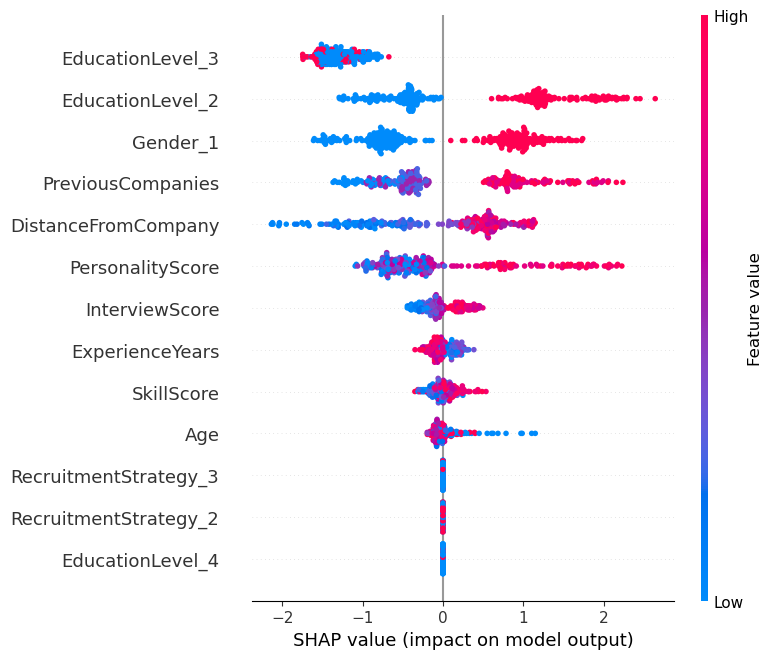

        Age  ExperienceYears  PreviousCompanies  DistanceFromCompany  \
0 -0.069348        -0.070585           0.859326             0.734566   
1 -0.113763        -0.019442           1.619033             1.073280   
2  0.162080         0.225157           0.575363            -0.947627   
3 -0.120828         0.199157          -0.397326            -0.539600   
4  0.016586         0.186428          -0.430113            -1.674302   

   InterviewScore  SkillScore  PersonalityScore  Gender_1  EducationLevel_2  \
0        0.384647    0.178103         -0.955624 -1.426563          1.203645   
1        0.214343   -0.019826          1.802917  1.153041          1.874220   
2        0.226859    0.442213         -0.262031 -0.514631         -0.324941   
3       -0.288985   -0.165712          0.719987 -0.812107         -0.830443   
4       -0.021867   -0.025806          1.593062  0.752587          1.604429   

   EducationLevel_3  EducationLevel_4  RecruitmentStrategy_2  \
0         -1.358759         

In [92]:
import shap
import pandas as pd

# Step 1: Wrap scaled data in DataFrame to retain feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

# Step 2: Create SHAP explainer for CatBoost model (or whichever model you're using)
explainer = shap.TreeExplainer(cbc)

# Step 3: Compute SHAP values
shap_values = explainer.shap_values(X_test_scaled_df)

# Step 4: Plot SHAP summary with feature names
shap.summary_plot(shap_values, X_test_scaled_df)

# Step 5: Convert SHAP values into a DataFrame for analysis
shap_df = pd.DataFrame(shap_values, columns=X_test_scaled_df.columns)

# Step 6: View the SHAP values (first few rows)
print(shap_df.head())


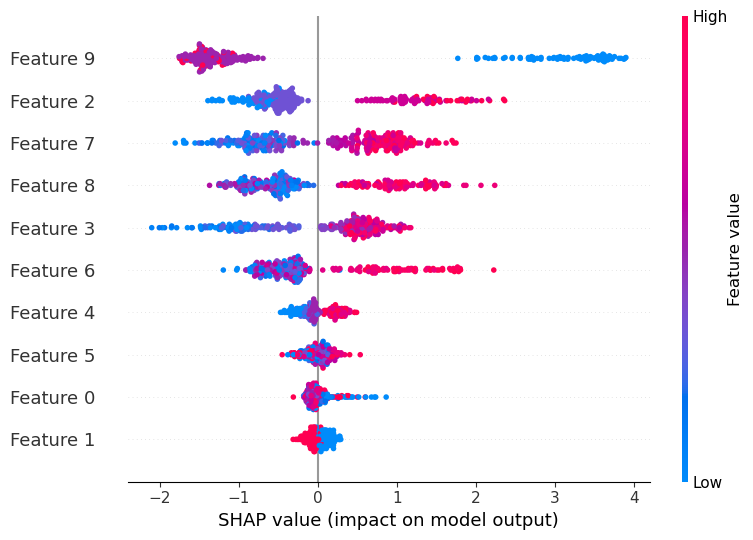

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [62]:
import shap

# Use TreeExplainer directly for CatBoost

shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled)


# Plot feature importance
shap.summary_plot(shap_values, X_test_encoded)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


In [68]:
print(X_train_scaled.shape)  # Should now be (1200, 13)
print(X_test_scaled.shape)   # Should now be (300, 13)


(1200, 13)
(300, 13)


In [73]:
print("Test shape:", test_samples.shape)
print("SHAP values shape:", np.array(shap_values).shape)


Test shape: (50, 13)
SHAP values shape: (50, 13, 1)


In [80]:
print("shap_values[0] shape:", np.array(shap_values[0]).shape)


shap_values[0] shape: (13, 1)


In [82]:
import shap
import numpy as np

# Ensure you're passing MULTIPLE rows (50, 13) to SHAP
test_samples = X_test_scaled[:50]

# Force the input into a 2D array with 50 samples
if test_samples.ndim == 1:
    test_samples = test_samples.reshape(1, -1)

print("SHAP Input shape:", test_samples.shape)  # Should be (50, 13)

# Rebuild SHAP explainer (use same background if already done)
explainer = shap.DeepExplainer(model, X_train_scaled[:100])

# Compute SHAP values for the full batch
shap_values = explainer.shap_values(test_samples)

# Check shape again
print("SHAP output shape:", np.array(shap_values[0]).shape)

# Only plot if SHAP and test sample shapes match
if np.array(shap_values[0]).shape == test_samples.shape:
    shap.summary_plot(shap_values[0], test_samples)
else:
    print("❌ Shape mismatch — cannot plot.")


SHAP Input shape: (50, 13)
SHAP output shape: (13, 1)
❌ Shape mismatch — cannot plot.


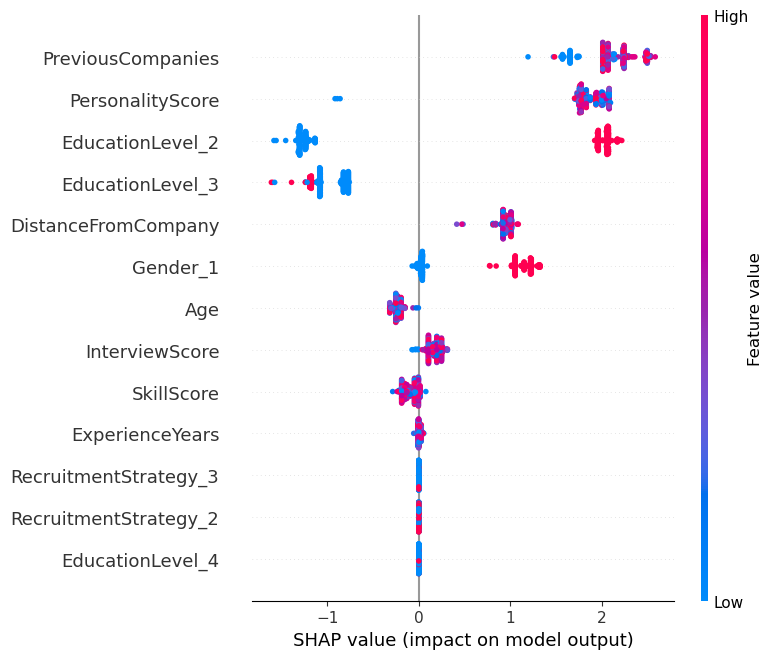

In [83]:
explainer = shap.TreeExplainer(cbc)  # or xgb_model
shap_values = explainer.shap_values(X_test_encoded)

shap.summary_plot(shap_values, X_test_encoded)


In [84]:
import lime
import lime.lime_tabular
import numpy as np

# Initialize the explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_encoded),
    feature_names=X_train_encoded.columns.tolist(),
    class_names=['Not Hired', 'Hired'],
    mode='classification'
)

# Explain a single instance (change the index to test others)
i = 5
exp = explainer.explain_instance(
    data_row=X_test_encoded.iloc[i],
    predict_fn=cbc.predict_proba  # or model.predict_proba
)

# Display explanation in notebook
exp.show_in_notebook()


C:\Users\USER\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\USER\anaconda3\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\USER\anaconda3\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use